In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Found 3064 files belonging to 7 classes.
Found 813 files belonging to 7 classes.
Classes: ['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']
Test Classes: ['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Feature extraction
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 692s 7s/step - accuracy: 0.3306 - loss: 2.0445 - val_accuracy: 0.6937 - val_loss: 1.3093 - learning_rate: 1.0000e-04
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 47s 484ms/step - accuracy: 0.5333 - loss: 1.3814 - val_accuracy: 0.8044 - val_loss: 0.8714 - learning_rate: 1.0000e-04
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 44s 456ms/step - accuracy: 0.6247 - loss: 1.0935 - val_accuracy: 0.8303 - val_loss: 0.6098 - learning_rate: 1.0000e-04
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 81s 450ms/step - accuracy: 0.6743 - loss: 0.9475 - val_accuracy: 0.8659 - val_loss: 0.4794 - learning_rate: 1.0000

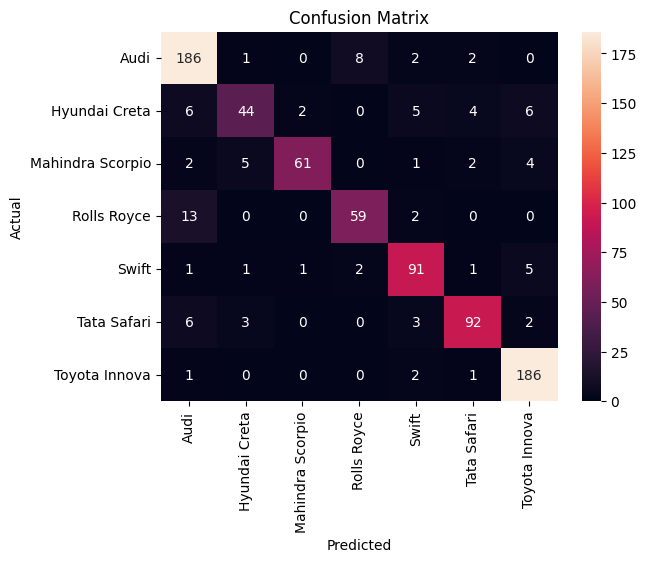

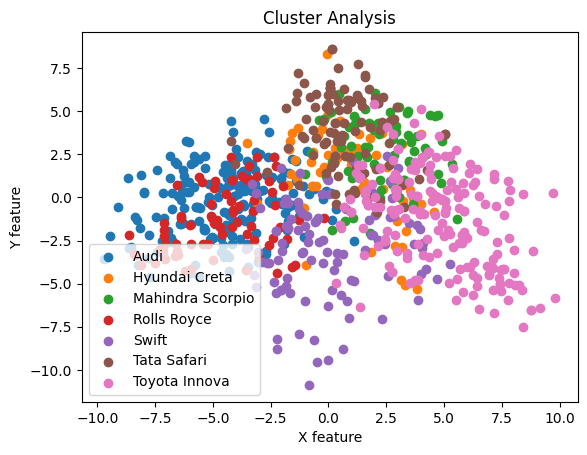

In [ ]:
#Asn 2
#This program is the part that builds the vehicle model and outputs clust1er analysis
#
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
import seaborn as sns

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 10
TRAIN_DIR = "/content/drive/MyDrive/Colab_data/train"
TEST_DIR = "/content/drive/MyDrive/Colab_data/test"

#This part loads the data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Test Classes:", test_dataset.class_names)

#Augment the data by applying random transformations
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

#Preprocess dataset with EfficientNet from Google
from tensorflow.keras.applications.efficientnet import preprocess_input

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(data_augmentation(x, training=True)), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

#Prefetch only, no caching
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

#Efficientnet model, B0
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
x = base_model.output
x = layers.GlobalAveragePooling2D()(x) #Pool xlayer
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
#Dropout eatures
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs=base_model.input, outputs=outputs)

#1st phase of model compiling
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  # safer LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

#Train the model for phase 1
print("\nFeature extraction")
model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks
)

#Phase 2 model fine tuning
print("\nModel fine tuning")
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks
)

# Mdl evaluation
loss, acc = model.evaluate(test_dataset)
print(f"\nFinal Test Accuracy: {acc:.4f}")

#X and y Prediction vs actual comparison part
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

#Make confusion matrix output
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Ft. classifier Clustering analysis
feature_extractor = models.Model(
    inputs=model.input,
    outputs=model.layers[-3].output
)

features = []
labels_list = []

for images, labels in test_dataset:
    feat = feature_extractor.predict(images, verbose=0)
    features.append(feat)
    labels_list.extend(labels.numpy())

features = np.concatenate(features)

pca = PCA(n_components=2)
reduced = pca.fit_transform(features)

plt.figure()
for i, label in enumerate(class_names):
    idx = np.array(labels_list) == i
    plt.scatter(reduced[idx, 0], reduced[idx, 1], label=label)

plt.legend()
plt.title("Cluster Analysis")
plt.xlabel("X feature")
plt.ylabel("Y feature")
plt.show()




In [ ]:
#Demonstrate cluster results and rest of colab program to class thur